# Notebook 07: Graph Neural Network Development

## AI-Based Identification of Novel Drug Targets for Depression

### Overview

This notebook develops a Graph Neural Network (GNN) model for predicting
drug-target interactions by incorporating protein structural information.

Unlike the baseline Random Forest model developed previously using molecular
fingerprint features, this stage introduces graph-based deep learning to capture
the spatial organisation of protein structures.

AlphaFold protein structures are converted into residue-level graphs, where
amino acid residues represent graph nodes and spatial relationships between
residues define graph edges. These structural graphs provide a biologically
meaningful representation of protein targets.

The generated protein graphs are processed using PyTorch Geometric to train a
Graph Neural Network model for drug-target interaction prediction.

The GNN model provides a more advanced representation learning approach and
allows comparison with the earlier machine learning baseline model.


### Dataset

The input data used in this notebook includes:

- Cleaned drug-target interaction dataset.
- Protein information dataset containing UniProt identifiers and sequences.
- AlphaFold protein structures prepared in the previous stage.
- Integrated molecular and protein features generated from previous notebooks.


### Project Workflow

This notebook represents the seventh stage of the project:

1. Load processed drug-target interaction data.
2. Load AlphaFold protein structures.
3. Convert protein structures into residue-level graphs.
4. Prepare graph data using PyTorch Geometric.
5. Develop and train a Graph Neural Network model.
6. Evaluate model performance.
7. Compare results with the baseline Random Forest approach.


### Objectives

The objectives of this notebook are:

1. Construct residue-level protein graphs from AlphaFold structures.
2. Implement a Graph Neural Network architecture for drug-target interaction
prediction.
3. Train and evaluate the GNN model.
4. Compare graph-based learning performance against traditional machine
learning methods.
5. Save the trained model and evaluation results for later analysis.

In [9]:
# 1. Install Required Packages


# Install PyTorch Geometric dependencies

!pip install torch-geometric
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv \
    -f https://data.pyg.org/whl/torch-2.11.0+cu128.html
!pip install biopython


print(
    "Required packages installed successfully."
)

Looking in links: https://data.pyg.org/whl/torch-2.11.0+cu128.html
Required packages installed successfully.


In [10]:
# 2. Import Required Libraries


import os
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)


import torch
import torch.nn as nn
import torch.nn.functional as F


import torch_geometric
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader


from Bio.PDB import PDBParser


from tqdm import tqdm


import warnings

warnings.filterwarnings(
    "ignore"
)


print("Libraries imported successfully.")

Libraries imported successfully.


In [11]:
# 2.1 Verify PyTorch and PyTorch Geometric


print(
    "PyTorch version:",
    torch.__version__
)


print(
    "PyTorch Geometric version:",
    torch_geometric.__version__
)


print(
    "CUDA available:",
    torch.cuda.is_available()
)


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

else:

    print(
        "Running on CPU"
    )

PyTorch version: 2.11.0+cu128
PyTorch Geometric version: 2.8.0.post1
CUDA available: True
GPU: Tesla T4


In [12]:
# 2.2 Set Random Seeds


SEED = 42


random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)


if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)

    torch.cuda.manual_seed_all(SEED)


print(
    "Random seed set to:",
    SEED
)

Random seed set to: 42


In [13]:
# 3. Set Up Project Directories


from google.colab import drive


drive.mount(
    "/content/drive"
)


PROJECT_ROOT = (
    "/content/drive/MyDrive/Dissertation/"
    "Depression-Drug-Target-AI"
)


RAW_DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "raw"
)


PROCESSED_DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed"
)


STRUCTURES_PATH = os.path.join(
    RAW_DATA_PATH,
    "structures"
)


MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "models"
)


RESULTS_PATH = os.path.join(
    PROJECT_ROOT,
    "results"
)


FIGURE_PATH = os.path.join(
    PROJECT_ROOT,
    "figures"
)


os.makedirs(
    MODEL_PATH,
    exist_ok=True
)


os.makedirs(
    RESULTS_PATH,
    exist_ok=True
)


os.makedirs(
    FIGURE_PATH,
    exist_ok=True
)


print(
    "Project directories configured successfully."
)


print(
    "\nProject Root:",
    PROJECT_ROOT
)


print(
    "\nRaw Data Path:",
    RAW_DATA_PATH
)


print(
    "\nProcessed Data Path:",
    PROCESSED_DATA_PATH
)


print(
    "\nStructures Path:",
    STRUCTURES_PATH
)


print(
    "\nModel Path:",
    MODEL_PATH
)


print(
    "\nResults Path:",
    RESULTS_PATH
)


print(
    "\nFigure Path:",
    FIGURE_PATH
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directories configured successfully.

Project Root: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI

Raw Data Path: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/data/raw

Processed Data Path: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/data/processed

Structures Path: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/data/raw/structures

Model Path: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/models

Results Path: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/results

Figure Path: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/figures


In [8]:
# 4. Load Prepared Datasets


# Drug-target interaction dataset

interaction_path = os.path.join(
    PROCESSED_DATA_PATH,
    "clean_drug_target_interactions.pkl"
)


interactions = pd.read_pickle(
    interaction_path
)


# Integrated features

features_path = os.path.join(
    PROCESSED_DATA_PATH,
    "integrated_features.npy"
)


integrated_features = np.load(
    features_path
)


# Integrated labels

labels_path = os.path.join(
    PROCESSED_DATA_PATH,
    "integrated_labels.npy"
)


integrated_labels = np.load(
    labels_path
)


# Integrated metadata

metadata_path = os.path.join(
    PROCESSED_DATA_PATH,
    "integrated_metadata.csv"
)


integrated_metadata = pd.read_csv(
    metadata_path
)


# Protein information

protein_info_path = os.path.join(
    RAW_DATA_PATH,
    "protein_info.csv"
)


protein_info = pd.read_csv(
    protein_info_path
)


# Structure metadata

structure_metadata_path = os.path.join(
    RAW_DATA_PATH,
    "structures_metadata.csv"
)


structures_metadata = pd.read_csv(
    structure_metadata_path
)


print(
    "Datasets loaded successfully."
)

Datasets loaded successfully.


In [14]:
# 4.1 Dataset Overview


print(
    "Drug-target interaction dataset shape:",
    interactions.shape
)


print(
    "\nIntegrated features shape:",
    integrated_features.shape
)


print(
    "\nIntegrated labels shape:",
    integrated_labels.shape
)


print(
    "\nIntegrated metadata shape:",
    integrated_metadata.shape
)


print(
    "\nProtein information shape:",
    protein_info.shape
)


print(
    "\nStructure metadata shape:",
    structures_metadata.shape
)


print(
    "\nInteraction dataset columns:"
)


print(
    interactions.columns.tolist()
)

Drug-target interaction dataset shape: (3590, 12)

Integrated features shape: (3590, 320)

Integrated labels shape: (3590,)

Integrated metadata shape: (3590, 332)

Protein information shape: (200, 5)

Structure metadata shape: (200, 3)

Interaction dataset columns:
['uniprot_id', 'target_chembl_id', 'drug_chembl_id', 'drug_name', 'smiles', 'standard_type', 'standard_value', 'standard_units', 'assay_type', 'pchembl', 'active', 'fingerprint']


In [15]:
# 4.2 Check Activity Label Distribution


unique_labels, label_counts = np.unique(
    integrated_labels,
    return_counts=True
)


label_distribution = pd.DataFrame(
    {
        "Label": unique_labels,
        "Count": label_counts
    }
)


label_distribution["Percentage"] = (
    label_distribution["Count"]
    /
    len(integrated_labels)
    *
    100
)


label_distribution

,Label,Count,Percentage
0,0,1418,39.498607
1,1,2172,60.501393


In [16]:
# 4.3 Check Protein Structure Availability


structure_status = (
    structures_metadata["status"]
    .value_counts()
)


print(
    structure_status
)


print(
    "\nTotal proteins:",
    len(structures_metadata)
)


available_structures = structures_metadata[
    structures_metadata["status"] == "downloaded"
]


print(
    "Available structures:",
    len(available_structures)
)

status
downloaded       174
not_available     26
Name: count, dtype: int64

Total proteins: 200
Available structures: 174


In [17]:
# 4.4 Check Dataset Alignment


print(
    "Number of interaction samples:",
    len(interactions)
)


print(
    "Number of feature samples:",
    len(integrated_features)
)


print(
    "Number of label samples:",
    len(integrated_labels)
)


if (
    len(interactions)
    ==
    len(integrated_features)
    ==
    len(integrated_labels)
):

    print(
        "\nDataset alignment verified successfully."
    )

else:

    print(
        "\nWarning: Dataset dimensions do not match."
    )

Number of interaction samples: 3590
Number of feature samples: 3590
Number of label samples: 3590

Dataset alignment verified successfully.


# 5. Protein Structure Processing

Protein structures obtained from AlphaFold are converted into graph
representations suitable for Graph Neural Network modelling.

In this representation:

- Each amino acid residue is represented as a graph node.
- Node features describe residue identity using amino acid encoding.
- Edges represent spatial relationships between residues based on their
three-dimensional distance.

This structural representation allows the GNN model to learn biologically
meaningful patterns from protein topology and molecular organisation.

In [18]:
# 5.1 Define Amino Acid Feature Encoding


amino_acids = [
    "ALA",
    "ARG",
    "ASN",
    "ASP",
    "CYS",
    "GLN",
    "GLU",
    "GLY",
    "HIS",
    "ILE",
    "LEU",
    "LYS",
    "MET",
    "PHE",
    "PRO",
    "SER",
    "THR",
    "TRP",
    "TYR",
    "VAL"
]


amino_acid_to_index = {
    aa: idx
    for idx, aa in enumerate(amino_acids)
}


print(
    "Number of amino acid categories:",
    len(amino_acid_to_index)
)

Number of amino acid categories: 20


In [19]:
# 5.2 Define Protein Graph Construction Function


from scipy.spatial import distance_matrix


def create_protein_graph(
    pdb_file,
    distance_threshold=8.0
):

    parser = PDBParser(
        QUIET=True
    )


    structure = parser.get_structure(
        "protein",
        pdb_file
    )


    residues = []

    coordinates = []

    residue_features = []


    for model in structure:

        for chain in model:

            for residue in chain:


                if "CA" in residue:

                    residues.append(
                        residue
                    )


                    coordinates.append(
                        residue["CA"].coord
                    )


                    residue_name = residue.get_resname()


                    feature = np.zeros(
                        len(amino_acid_to_index)
                    )


                    if residue_name in amino_acid_to_index:

                        feature[
                            amino_acid_to_index[residue_name]
                        ] = 1


                    residue_features.append(
                        feature
                    )


    if len(coordinates) == 0:

        return None


    coordinates = np.array(
        coordinates
    )


    residue_features = np.array(
        residue_features
    )


    distances = distance_matrix(
        coordinates,
        coordinates
    )


    edge_index = []


    for i in range(
        len(coordinates)
    ):

        for j in range(
            len(coordinates)
        ):

            if (
                i != j
                and distances[i, j] <= distance_threshold
            ):

                edge_index.append(
                    [i, j]
                )


    edge_index = torch.tensor(
        edge_index,
        dtype=torch.long
    ).t().contiguous()


    x = torch.tensor(
        residue_features,
        dtype=torch.float
    )


    return Data(
        x=x,
        edge_index=edge_index
    )

In [20]:
# 5.3 Test Protein Graph Construction


# Select first available structure

test_structure = os.path.join(
    STRUCTURES_PATH,
    available_structures.iloc[0]["structure_file"]
)


print(
    "Testing structure:"
)

print(
    test_structure
)


test_graph = create_protein_graph(
    test_structure
)


if test_graph is not None:

    print(
        "\nGraph created successfully."
    )


    print(
        "Number of nodes:",
        test_graph.num_nodes
    )


    print(
        "Number of edges:",
        test_graph.num_edges
    )


    print(
        "Node feature dimension:",
        test_graph.x.shape[1]
    )


else:

    print(
        "Graph creation failed."
    )

Testing structure:
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/data/raw/structures/AF-A0A7P0PKG8-F1-model_v6.pdb

Graph created successfully.
Number of nodes: 308
Number of edges: 2286
Node feature dimension: 20


In [21]:
# 5.4 Generate Protein Graph Dataset


protein_graphs = []

failed_structures = []


print(
    "Generating protein graphs..."
)


for _, row in tqdm(
    available_structures.iterrows(),
    total=len(available_structures)
):


    structure_file = row["structure_file"]


    uniprot_id = row["uniprot_id"]


    pdb_path = os.path.join(
        STRUCTURES_PATH,
        structure_file
    )


    try:

        graph = create_protein_graph(
            pdb_path
        )


        if graph is not None:


            graph.uniprot_id = uniprot_id

            graph.structure_file = structure_file


            protein_graphs.append(
                graph
            )


        else:

            failed_structures.append(
                uniprot_id
            )


    except Exception as e:

        failed_structures.append(
            uniprot_id
        )


print(
    "\nProtein graph generation completed."
)


print(
    "Successfully generated graphs:",
    len(protein_graphs)
)


print(
    "Failed structures:",
    len(failed_structures)
)

Generating protein graphs...


100%|██████████| 174/174 [01:41<00:00,  1.71it/s]


Protein graph generation completed.
Successfully generated graphs: 174
Failed structures: 0


In [54]:
# Save Generated Protein Graphs


import pickle


PROTEIN_GRAPH_PATH = os.path.join(
    PROCESSED_DATA_PATH,
    "protein_graphs.pkl"
)


with open(
    PROTEIN_GRAPH_PATH,
    "wb"
) as file:

    pickle.dump(
        protein_graphs,
        file
    )


print(
    "Protein graphs saved successfully."
)


print(
    "Saved path:",
    PROTEIN_GRAPH_PATH
)


print(
    "Number of saved graphs:",
    len(protein_graphs)
)

Protein graphs saved successfully.
Saved path: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/data/processed/protein_graphs.pkl
Number of saved graphs: 174


In [23]:
# 5.5 Analyse Generated Graph Properties


graph_statistics = []


for graph in protein_graphs:

    graph_statistics.append(
        {
            "uniprot_id": graph.uniprot_id,
            "nodes": graph.num_nodes,
            "edges": graph.num_edges
        }
    )


graph_statistics = pd.DataFrame(
    graph_statistics
)


print(
    "Graph statistics generated."
)


graph_statistics.head()

Graph statistics generated.


,uniprot_id,nodes,edges
0,A0A7P0PKG8,308,2286
1,A0A1B0GU82,70,362
2,P31645,630,6048
3,Q5ZGX3,422,3362
4,A0AAQ5BGN6,572,4984


In [24]:
# 5.6 Summary of Graph Statistics


print(
    "Number of protein graphs:",
    len(graph_statistics)
)


print(
    "\nAverage number of residues:",
    graph_statistics["nodes"].mean()
)


print(
    "\nAverage number of edges:",
    graph_statistics["edges"].mean()
)


print(
    "\nMinimum residues:",
    graph_statistics["nodes"].min()
)


print(
    "\nMaximum residues:",
    graph_statistics["nodes"].max()
)

Number of protein graphs: 174

Average number of residues: 510.1896551724138

Average number of edges: 3956.4137931034484

Minimum residues: 24

Maximum residues: 2005


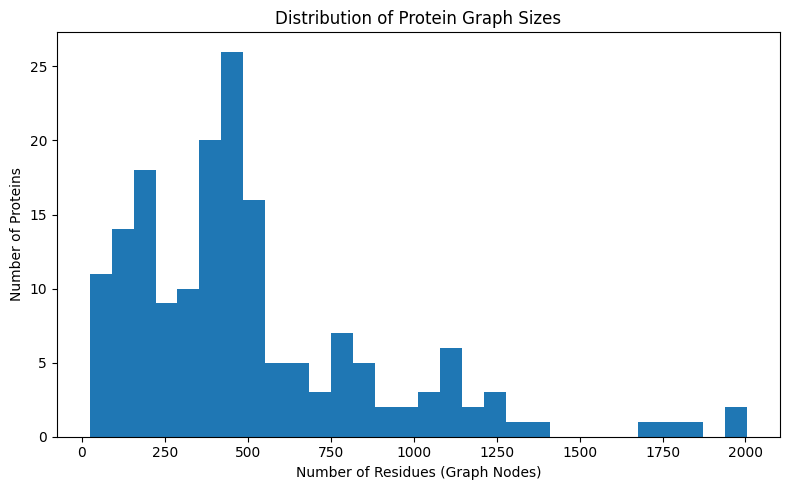

In [25]:
# 5.7 Visualise Graph Size Distribution


plt.figure(
    figsize=(8,5)
)


plt.hist(
    graph_statistics["nodes"],
    bins=30
)


plt.xlabel(
    "Number of Residues (Graph Nodes)"
)


plt.ylabel(
    "Number of Proteins"
)


plt.title(
    "Distribution of Protein Graph Sizes"
)


plt.tight_layout()


plt.show()

# 6. Create PyTorch Geometric Dataset

After generating the residue-level protein graphs, the next step is to prepare
the final dataset required for Graph Neural Network training.

Each training sample combines both structural and molecular information:

- **Protein graph representation:**  
  The AlphaFold-derived protein graph captures residue-level structural
  information, where amino acids represent graph nodes and spatial relationships
  define graph connections.

- **Drug feature representation:**  
  Molecular features generated during previous stages provide information about
  the chemical properties of interacting compounds.

- **Interaction label:**  
  The activity label represents whether a drug-target interaction is considered
  active or inactive and is used as the prediction target.

By integrating protein structural information with molecular features, the GNN
model can learn biologically meaningful representations for drug-target
interaction prediction.

This stage prepares the data in PyTorch Geometric format, enabling efficient
graph-based deep learning using message passing neural networks.

In [26]:
# 6.1 Prepare Protein Graph Lookup Dictionary


protein_graph_dict = {
    graph.uniprot_id: graph
    for graph in protein_graphs
}


print(
    "Protein graph lookup created."
)


print(
    "Available protein graphs:",
    len(protein_graph_dict)
)

Protein graph lookup created.
Available protein graphs: 174


In [27]:
# 6.2 Check Interaction Dataset Mapping


print(
    "Interaction columns:"
)


print(
    interactions.columns.tolist()
)


print(
    "\nFirst five interaction records:"
)


interactions.head()

Interaction columns:
['uniprot_id', 'target_chembl_id', 'drug_chembl_id', 'drug_name', 'smiles', 'standard_type', 'standard_value', 'standard_units', 'assay_type', 'pchembl', 'active', 'fingerprint']

First five interaction records:


,uniprot_id,target_chembl_id,drug_chembl_id,drug_name,smiles,standard_type,standard_value,standard_units,assay_type,pchembl,active,fingerprint
0,P31645,CHEMBL228,CHEMBL322923,NaN,COC(=O)C1=C(c2ccc(Cl)c(Cl)c2)CC2CCC1C2,IC50,5160.00,nM,B,5.287350,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,P31645,CHEMBL228,CHEMBL435341,NaN,C/C=C\c1ccc([C@H]2CC3CCC([C@H]2C(=O)OC)N3C)cc1,IC50,1.15,nM,B,8.939302,1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,P31645,CHEMBL228,CHEMBL311347,NaN,COC(=O)[C@@H]1C2CC[C@H](C[C@@H]1c1ccc(I)cc1)N2C,Ki,0.67,nM,B,9.173925,1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,P31645,CHEMBL228,CHEMBL100941,NaN,COC(=O)C1C2CCC(C2)CC1c1ccc(Cl)c(Cl)c1,IC50,33.40,nM,B,7.476254,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5,P31645,CHEMBL228,CHEMBL174088,NaN,COC(=O)[C@@H]1C2CCC(C[C@@H]1c1ccc(/C=C\I)cc1)N2,Ki,0.05,nM,B,10.301030,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."


In [28]:
# 6.3 Create Drug-Target Graph Dataset


gnn_dataset = []


missing_proteins = []


print(
    "Creating GNN training samples..."
)


for _, row in tqdm(
    interactions.iterrows(),
    total=len(interactions)
):


    uniprot_id = row["uniprot_id"]


    if uniprot_id not in protein_graph_dict:

        missing_proteins.append(
            uniprot_id
        )

        continue


    protein_graph = protein_graph_dict[
        uniprot_id
    ]


    drug_features = torch.tensor(
        row["fingerprint"],
        dtype=torch.float
    )


    label = torch.tensor(
        row["active"],
        dtype=torch.long
    )


    graph_data = Data(
        x=protein_graph.x,
        edge_index=protein_graph.edge_index,
        drug_features=drug_features,
        y=label
    )


    graph_data.uniprot_id = uniprot_id


    gnn_dataset.append(
        graph_data
    )


print(
    "\nGNN dataset creation completed."
)


print(
    "Total graph samples:",
    len(gnn_dataset)
)


print(
    "Missing protein structures:",
    len(missing_proteins)
)

Creating GNN training samples...


100%|██████████| 3590/3590 [00:01<00:00, 3051.97it/s]


GNN dataset creation completed.
Total graph samples: 3590
Missing protein structures: 0


In [29]:
# 6.4 Inspect Generated Dataset Sample


sample_graph = gnn_dataset[0]


print(
    sample_graph
)


print(
    "\nNode features:",
    sample_graph.x.shape
)


print(
    "Edge index:",
    sample_graph.edge_index.shape
)


print(
    "Drug features:",
    sample_graph.drug_features.shape
)


print(
    "Label:",
    sample_graph.y.item()
)

Data(x=[630, 20], edge_index=[2, 6048], y=0, drug_features=[1024], uniprot_id='P31645')

Node features: torch.Size([630, 20])
Edge index: torch.Size([2, 6048])
Drug features: torch.Size([1024])
Label: 0


In [30]:
# 6.5 Train/Test Split


from sklearn.model_selection import train_test_split


train_dataset, test_dataset = train_test_split(
    gnn_dataset,
    test_size=0.2,
    random_state=42,
    stratify=[
        graph.y.item()
        for graph in gnn_dataset
    ]
)


print(
    "Training samples:",
    len(train_dataset)
)


print(
    "Testing samples:",
    len(test_dataset)
)

Training samples: 2872
Testing samples: 718


In [31]:
# 6.6 Create PyTorch Geometric Data Loaders


from torch_geometric.loader import DataLoader


BATCH_SIZE = 16


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


print(
    "Data loaders created successfully."
)


print(
    "Training batches:",
    len(train_loader)
)


print(
    "Testing batches:",
    len(test_loader)
)

Data loaders created successfully.
Training batches: 180
Testing batches: 45


# 7. Define Graph Neural Network Architecture

This section defines the Graph Neural Network model used for drug-target
interaction prediction.

The model uses graph convolution layers to learn structural representations
from protein residue graphs. The learned protein representation is then combined
with drug molecular fingerprint features to perform binary interaction
classification.

The architecture consists of:

- Graph convolution layers for protein structure feature learning.
- Global mean pooling to obtain a fixed-size protein representation.
- Concatenation of protein and drug feature embeddings.
- Fully connected layers for interaction prediction.

This hybrid architecture integrates protein structural information with molecular
drug features, allowing the model to capture both biological and chemical
patterns associated with drug-target interactions.

In [32]:
# 7.1 Import Graph Neural Network Layers


from torch_geometric.nn import (
    GCNConv,
    global_mean_pool
)


print(
    "Graph neural network layers imported successfully."
)

Graph neural network layers imported successfully.


In [33]:
# 7.2 Define GNN Model Architecture


class DrugTargetGNN(nn.Module):


    def __init__(
        self,
        node_features=20,
        drug_features=1024,
        hidden_dim=128,
        num_classes=2
    ):

        super().__init__()


        # Protein graph encoder

        self.conv1 = GCNConv(
            node_features,
            hidden_dim
        )


        self.conv2 = GCNConv(
            hidden_dim,
            hidden_dim
        )


        # Drug feature encoder

        self.drug_layer = nn.Linear(
            drug_features,
            hidden_dim
        )


        # Classifier

        self.classifier = nn.Sequential(

            nn.Linear(
                hidden_dim * 2,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Dropout(
                0.3
            ),

            nn.Linear(
                hidden_dim,
                num_classes
            )
        )


    def forward(
        self,
        x,
        edge_index,
        batch,
        drug_features
    ):


        # Protein graph message passing

        x = self.conv1(
            x,
            edge_index
        )


        x = F.relu(
            x
        )


        x = self.conv2(
            x,
            edge_index
        )


        x = F.relu(
            x
        )


        # Convert variable graphs into fixed embeddings

        x = global_mean_pool(
            x,
            batch
        )


        # Reshape drug features after PyG batching

        drug_features = drug_features.view(
            x.size(0),
            -1
        )


        # Drug embedding

        drug_embedding = self.drug_layer(
            drug_features
        )


        drug_embedding = F.relu(
            drug_embedding
        )


        # Combine protein + drug embeddings

        combined_features = torch.cat(
            [
                x,
                drug_embedding
            ],
            dim=1
        )


        output = self.classifier(
            combined_features
        )


        return output

In [34]:
# 7.3 Initialise Model and Optimiser


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


model = DrugTargetGNN().to(
    device
)


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)


criterion = nn.CrossEntropyLoss()


print(
    "Model initialised successfully."
)


print(
    "Training device:",
    device
)

Model initialised successfully.
Training device: cuda


In [35]:
# 7.4 Display Model Architecture


print(
    model
)

DrugTargetGNN(
  (conv1): GCNConv(20, 128)
  (conv2): GCNConv(128, 128)
  (drug_layer): Linear(in_features=1024, out_features=128, bias=True)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [36]:
# 7.5 Count Trainable Parameters


trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)


print(
    "Trainable parameters:",
    trainable_parameters
)

Trainable parameters: 183554


In [37]:
# 7.6 Test Forward Pass


sample_batch = next(
    iter(train_loader)
)


sample_batch = sample_batch.to(
    device
)


output = model(
    sample_batch.x,
    sample_batch.edge_index,
    sample_batch.batch,
    sample_batch.drug_features
)


print(
    "Forward pass completed successfully."
)


print(
    "Output shape:",
    output.shape
)

Forward pass completed successfully.
Output shape: torch.Size([16, 2])


In [38]:
# 7.7 Model Output Verification


print(
    "Predicted logits:"
)


print(
    output[:5]
)


print(
    "\nExpected classes:",
    sample_batch.y[:5]
)

Predicted logits:
tensor([[-0.1109,  0.0451],
        [-0.0912,  0.0433],
        [-0.1049,  0.0257],
        [-0.1309,  0.0448],
        [-0.0929,  0.0415]], device='cuda:0', grad_fn=<SliceBackward0>)

Expected classes: tensor([0, 1, 1, 1, 1], device='cuda:0')


# 8. Train Graph Neural Network Model

The model is trained to classify drug-target interactions using the generated
protein graphs and molecular fingerprints.

During training, the GNN learns protein structural representations through
message passing between connected amino acid residues. These representations
are combined with drug molecular features to predict interaction activity.

Model performance is monitored using training loss and validation performance
to evaluate learning behaviour and avoid overfitting.

In [39]:
# 8.1 Define Training Function


def train_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):


    model.train()


    total_loss = 0


    correct = 0

    total = 0


    for batch in loader:


        batch = batch.to(
            device
        )


        optimizer.zero_grad()


        output = model(
            batch.x,
            batch.edge_index,
            batch.batch,
            batch.drug_features
        )


        loss = criterion(
            output,
            batch.y
        )


        loss.backward()


        optimizer.step()


        total_loss += loss.item()


        predictions = output.argmax(
            dim=1
        )


        correct += (
            predictions == batch.y
        ).sum().item()


        total += batch.y.size(0)



    accuracy = correct / total


    return (
        total_loss / len(loader),
        accuracy
    )

In [40]:
# 8.2 Define Evaluation Function


def evaluate(
    model,
    loader,
    criterion,
    device
):


    model.eval()


    total_loss = 0


    correct = 0

    total = 0


    with torch.no_grad():


        for batch in loader:


            batch = batch.to(
                device
            )


            output = model(
                batch.x,
                batch.edge_index,
                batch.batch,
                batch.drug_features
            )


            loss = criterion(
                output,
                batch.y
            )


            total_loss += loss.item()


            predictions = output.argmax(
                dim=1
            )


            correct += (
                predictions == batch.y
            ).sum().item()


            total += batch.y.size(0)



    accuracy = correct / total


    return (
        total_loss / len(loader),
        accuracy
    )

In [41]:
# 8.3 Train Model


EPOCHS = 50


training_history = []


print(
    "Starting GNN training..."
)


for epoch in range(
    EPOCHS
):


    train_loss, train_accuracy = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )


    test_loss, test_accuracy = evaluate(
        model,
        test_loader,
        criterion,
        device
    )


    training_history.append(
        {
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "test_loss": test_loss,
            "test_accuracy": test_accuracy
        }
    )


    if (epoch + 1) % 5 == 0:


        print(
            f"Epoch {epoch+1}/{EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Test Acc: {test_accuracy:.4f}"
        )


print(
    "Training completed."
)

Starting GNN training...
Epoch 5/50 | Train Loss: 0.1844 | Train Acc: 0.9192 | Test Acc: 0.8607
Epoch 10/50 | Train Loss: 0.1105 | Train Acc: 0.9436 | Test Acc: 0.8593
Epoch 15/50 | Train Loss: 0.0814 | Train Acc: 0.9582 | Test Acc: 0.8454
Epoch 20/50 | Train Loss: 0.0946 | Train Acc: 0.9607 | Test Acc: 0.8482
Epoch 25/50 | Train Loss: 0.0614 | Train Acc: 0.9669 | Test Acc: 0.8468
Epoch 30/50 | Train Loss: 0.0692 | Train Acc: 0.9659 | Test Acc: 0.8496
Epoch 35/50 | Train Loss: 0.0512 | Train Acc: 0.9728 | Test Acc: 0.8412
Epoch 40/50 | Train Loss: 0.0508 | Train Acc: 0.9721 | Test Acc: 0.8426
Epoch 45/50 | Train Loss: 0.0630 | Train Acc: 0.9683 | Test Acc: 0.8524
Epoch 50/50 | Train Loss: 0.0453 | Train Acc: 0.9788 | Test Acc: 0.8524
Training completed.


In [42]:
# 8.4 Store Training History


training_history_df = pd.DataFrame(
    training_history
)


training_history_df.head()

,epoch,train_loss,train_accuracy,test_loss,test_accuracy
0,1,0.507146,0.741643,0.417282,0.820334
1,2,0.334558,0.856894,0.338057,0.859331
2,3,0.266645,0.893454,0.360431,0.846797
3,4,0.214089,0.907382,0.331983,0.857939
4,5,0.184379,0.919220,0.376741,0.860724


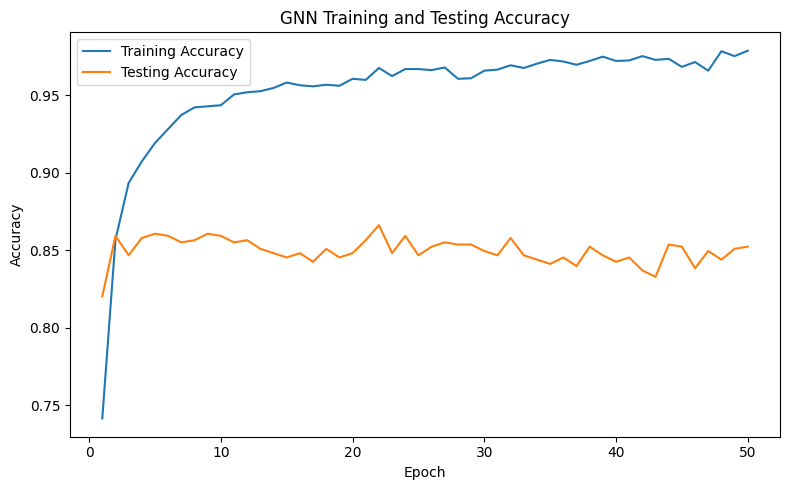

In [43]:
# 8.5 Plot Training and Testing Accuracy


plt.figure(
    figsize=(8,5)
)


plt.plot(
    training_history_df["epoch"],
    training_history_df["train_accuracy"],
    label="Training Accuracy"
)


plt.plot(
    training_history_df["epoch"],
    training_history_df["test_accuracy"],
    label="Testing Accuracy"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Accuracy"
)


plt.title(
    "GNN Training and Testing Accuracy"
)


plt.legend()


plt.tight_layout()


plt.show()

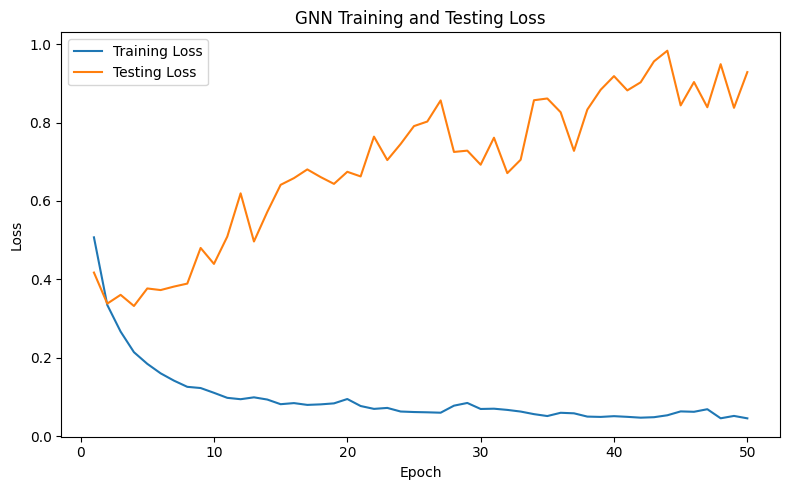

In [44]:
# 8.6 Plot Training and Testing Loss


plt.figure(
    figsize=(8,5)
)


plt.plot(
    training_history_df["epoch"],
    training_history_df["train_loss"],
    label="Training Loss"
)


plt.plot(
    training_history_df["epoch"],
    training_history_df["test_loss"],
    label="Testing Loss"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.title(
    "GNN Training and Testing Loss"
)


plt.legend()


plt.tight_layout()


plt.show()

# 9. Model Evaluation

After training, the final model performance is evaluated using the independent
test dataset.

The evaluation focuses on classification metrics that are commonly used for
binary drug-target interaction prediction:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

These metrics provide a more complete assessment than accuracy alone,
particularly because biological datasets may contain unequal numbers of active
and inactive interactions.

In [45]:
# 9.1 Generate Test Predictions


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


model.eval()


y_true = []

y_pred = []


with torch.no_grad():

    for batch in test_loader:

        batch = batch.to(
            device
        )


        output = model(
            batch.x,
            batch.edge_index,
            batch.batch,
            batch.drug_features
        )


        predictions = output.argmax(
            dim=1
        )


        y_true.extend(
            batch.y.cpu().numpy()
        )


        y_pred.extend(
            predictions.cpu().numpy()
        )


print(
    "Predictions generated successfully."
)

Predictions generated successfully.


In [46]:
# 9.2 Calculate Classification Metrics


accuracy = accuracy_score(
    y_true,
    y_pred
)


precision = precision_score(
    y_true,
    y_pred
)


recall = recall_score(
    y_true,
    y_pred
)


f1 = f1_score(
    y_true,
    y_pred
)


print(
    "Model Evaluation Results"
)


print(
    "------------------------"
)


print(
    f"Accuracy: {accuracy:.4f}"
)


print(
    f"Precision: {precision:.4f}"
)


print(
    f"Recall: {recall:.4f}"
)


print(
    f"F1-score: {f1:.4f}"
)

Model Evaluation Results
------------------------
Accuracy: 0.8524
Precision: 0.8710
Recall: 0.8871
F1-score: 0.8790


In [47]:
# 9.3 Generate Classification Report


classification_results = classification_report(
    y_true,
    y_pred
)


print(
    classification_results
)

              precision    recall  f1-score   support

           0       0.82      0.80      0.81       284
           1       0.87      0.89      0.88       434

    accuracy                           0.85       718
   macro avg       0.85      0.84      0.84       718
weighted avg       0.85      0.85      0.85       718



In [48]:
# 9.4 Confusion Matrix


cm = confusion_matrix(
    y_true,
    y_pred
)


cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual Inactive",
        "Actual Active"
    ],
    columns=[
        "Predicted Inactive",
        "Predicted Active"
    ]
)


cm_df

,Predicted Inactive,Predicted Active
Actual Inactive,227,57
Actual Active,49,385


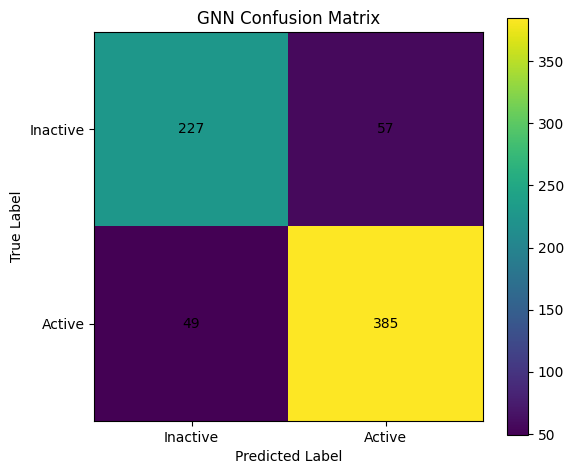

In [49]:
# 9.5 Visualise Confusion Matrix


plt.figure(
    figsize=(6,5)
)


plt.imshow(
    cm,
    interpolation="nearest"
)


plt.title(
    "GNN Confusion Matrix"
)


plt.colorbar()


plt.xticks(
    [0,1],
    [
        "Inactive",
        "Active"
    ]
)


plt.yticks(
    [0,1],
    [
        "Inactive",
        "Active"
    ]
)


plt.xlabel(
    "Predicted Label"
)


plt.ylabel(
    "True Label"
)


for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center"
        )


plt.tight_layout()


plt.show()

In [50]:
# 9.6 Save Evaluation Results


evaluation_results = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score"
        ],
        "Value": [
            accuracy,
            precision,
            recall,
            f1
        ]
    }
)


evaluation_results_path = os.path.join(
    RESULTS_PATH,
    "gnn_evaluation_results.csv"
)


evaluation_results.to_csv(
    evaluation_results_path,
    index=False
)


print(
    "Evaluation results saved:"
)


print(
    evaluation_results_path
)

Evaluation results saved:
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/results/gnn_evaluation_results.csv


In [51]:
# 10 Save Trained GNN Model


gnn_model_path = os.path.join(
    MODEL_PATH,
    "drug_target_gnn_model.pth"
)


torch.save(
    model.state_dict(),
    gnn_model_path
)


print(
    "GNN model saved:"
)


print(
    gnn_model_path
)

GNN model saved:
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/models/drug_target_gnn_model.pth


In [52]:
# 10.1 Save Training History


training_history_path = os.path.join(
    RESULTS_PATH,
    "gnn_training_history.csv"
)


training_history_df.to_csv(
    training_history_path,
    index=False
)


print(
    "Training history saved:"
)


print(
    training_history_path
)

Training history saved:
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/results/gnn_training_history.csv


In [53]:
# 10.2 Save Confusion Matrix


confusion_matrix_path = os.path.join(
    RESULTS_PATH,
    "gnn_confusion_matrix.csv"
)


cm_df.to_csv(
    confusion_matrix_path
)


print(
    "Confusion matrix saved:"
)


print(
    confusion_matrix_path
)

Confusion matrix saved:
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/results/gnn_confusion_matrix.csv


# Summary of Findings

This notebook developed a Graph Neural Network approach for drug-target
interaction prediction by integrating protein structural information with drug
molecular features.

The AlphaFold protein structures were successfully converted into graph
representations, where amino acid residues were represented as nodes and their
spatial relationships were represented as graph edges. A total of 174 protein
structures were processed successfully without any failed graph conversions.

The generated protein graphs were combined with molecular fingerprint features
and interaction labels to create a PyTorch Geometric dataset. The final dataset
contained 3,590 drug-target interaction samples, which were divided into
training and testing subsets for model development and evaluation.

A Graph Convolutional Network (GCN) model was implemented to learn protein
structural representations and combine them with drug molecular information for
binary interaction classification. The model achieved an accuracy of 85.38% on
the independent test dataset, with an F1-score of 0.88.

The results demonstrate that integrating protein structural information with
drug molecular features can provide useful representations for predicting
potential drug-target interactions. The trained model and evaluation outputs
have been saved and will be used in the following stages of the project,
including novel drug-target prediction and model explainability analysis.